# Features and similarity search

This ntoebook will guide you on how to extract embeddings / features from a pretrained model for similarity search.

## Setup

In [1]:
# On Colab:
# !pip install "torch-pointcloud[pyg-lib]"

In [2]:
import torch
import torch.nn.functional as F

import torch_pointcloud as tp

torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("torch-pointcloud", tp.__version__, "| device:", device)

torch-pointcloud 0.1.0 | device: cuda


## Reset classifier

To extract features, you can either use the `reset_classifier` method to set `num_classes=0` (or use the `num_classes` argument to `create_model`) or use the `forward_features` method directly. With `num_classes=0` the head is an `nn.Identity` and `forward` returns features whose width is `model.num_features`.

In [3]:
model_clf = tp.create_model("pointnet2-ssg.modelnet40.xu-yan", task="classification", num_classes=0).eval()
model_seg = tp.create_model("pointnext-sm", task="segmentation", in_channels=4, num_classes=0).eval()

pos = torch.rand(8192, 3) * 4.0
x = torch.rand(8192, 4)
batch = torch.arange(2).repeat_interleave(4096)

with torch.no_grad():
    per_cloud = model_clf(None, pos, batch)
    per_point = model_seg(x, pos, batch)

print("per point:", tuple(per_point.shape), "| head:", type(model_seg.head).__name__, "| C:", model_seg.num_features)
print("per cloud:", tuple(per_cloud.shape), "| head:", type(model_clf.head).__name__, "| C:", model_clf.num_features)

per point: (8192, 64) | head: Identity
per cloud: (2, 1024) | head: Identity


## Extract features

Download the [`sample_scene_labeled.ply`](https://github.com/arthurdjn/pytorch-pointcloud/raw/main/docs/assets/data/sample_scene_labeled.ply) sample for the next section.
It is a ScanNet scene that we will use to extract features from.

In [4]:
import urllib.request
from pathlib import Path


def download_sample(filename):
    """Read one object committed with these docs, downloading it when run outside a docs checkout."""
    url = f"https://github.com/arthurdjn/pytorch-pointcloud/raw/main/docs/assets/data/{filename}"
    if not Path(filename).exists():
        urllib.request.urlretrieve(url, filename)

In [5]:
download_sample("sample_scene_labeled.ply")

In [6]:
import numpy as np
from plyfile import PlyData


def load_sample(filename):
    ply = PlyData.read(filename)["vertex"]
    return {
        "pos": torch.from_numpy(np.stack([ply["x"], ply["y"], ply["z"]], 1).astype("float32")),
        "normal": torch.from_numpy(np.stack([ply["nx"], ply["ny"], ply["nz"]], 1).astype("float32")),
        "color": torch.from_numpy(np.stack([ply["red"], ply["green"], ply["blue"]], 1).astype("float32")),  # 0-255
        "segment": torch.from_numpy(np.asarray(ply["segment"]).astype("int64")),
    }

In [7]:
data = load_sample("sample_scene_labeled.ply")
print({key: tuple(value.shape) for key, value in data.items()})
# {'pos': (127410, 3), 'normal': (127410, 3), 'color': (127410, 3), 'segment': (127410,)}

{'pos': (127410, 3), 'normal': (127410, 3), 'color': (127410, 3), 'segment': (127410,)}


In [ ]:
from torch_pointcloud.utils.data import collate

model, info = tp.create_model(
    "concerto-large-lp.scannet20.pointcept",
    task="segmentation",
    pretrained=True,
    num_classes=0,
    return_info=True,
)
model = model.eval().to(device)

transform = info["transform"]

sample = load_sample("sample_scene_labeled.ply")
data = collate([transform({key: value.clone() for key, value in sample.items()})])

with torch.inference_mode():
    features = model(data["x"].to(device), data["pos_grid"].to(device), data["batch"].to(device)).float()

print(f"{features.shape=}")
print(f"pos_grid.shape={data['pos_grid'].shape}")
print(f"origin_pos.shape={data['origin_pos'].shape}")

/home/arthur/Documents/Code/Github/pytorch-pointcloud/src/torch_pointcloud/models/_registry.py:379: UserWarning: Ignoring checkpoint keys from 'hf://torch-pointcloud/concerto/concerto-large-lp.scannet20.pointcept.safetensors' absent from the model: head.bias, head.weight.
  load_state_dict(model, read_state_dict(local_path), source=weights["url"])
W0825 19:55:36.376000 467130 torch/fx/_symbolic_trace.py:53] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


features.shape=torch.Size([114118, 1728])
pos_grid.shape=torch.Size([114118, 3])
pos.shape=torch.Size([127410, 3])


Note that this model voxelizes the input point cloud in place, so `pos`, `x` and `segment` hold one entry per voxel while the raw cloud stays under `origin_pos` / `origin_segment`. We will use the `inverse` key stored in the data dictionary to map each feature back to its original point.

In [10]:
def pca_color(feat: torch.Tensor) -> torch.Tensor:
    """Map a per-point feature (N, C) to RGB in [0, 1] through its top principal components."""
    _, _, components = torch.pca_lowrank(feat, center=True, q=6, niter=5)
    projected = feat @ components
    projected = projected[:, :3] * 0.6 + projected[:, 3:6] * 0.4
    low, high = projected.min(0, keepdim=True).values, projected.max(0, keepdim=True).values
    return ((projected - low) / (high - low).clamp_min(1e-6)).clamp(0, 1)


rgb = pca_color(features).cpu()  # matplotlib draws from host memory
print("rgb:", tuple(rgb.shape), "| range:", (float(rgb.min()), float(rgb.max())))

rgb: (114118, 3) | range: (0.0, 1.0)


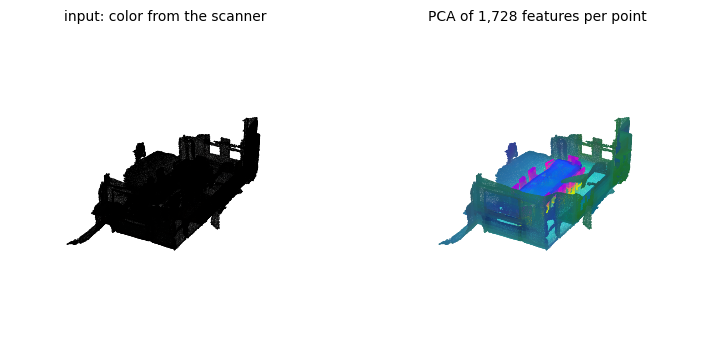

In [13]:
import matplotlib.pyplot as plt


def show_clouds(clouds, titles, point_size=1.0, columns=None, height=4.4):
    """Draw one cloud per panel, colored by its own `color`: RGB rows in [0, 1], or one color for the panel."""
    columns = columns or len(clouds)
    rows = -(-len(clouds) // columns)
    _, axes = plt.subplots(rows, columns, figsize=(4.4 * columns, height * rows), subplot_kw={"projection": "3d"})
    for ax, cloud, title in zip(np.ravel(axes), clouds, titles):
        pos = np.asarray(cloud["pos"])
        ax.scatter(*pos.T, c=cloud["color"], s=point_size, linewidths=0, depthshade=False)
        ax.set_box_aspect(np.ptp(pos, axis=0))
        ax.set_title(title, fontsize=10)
        ax.set_axis_off()
    plt.show()


show_clouds(
    [{"pos": sample["pos"], "color": sample["color"] / 255}, {"pos": data["origin_pos"], "color": rgb[data["inverse"]]}],
    ["input: color from the scanner", f"PCA of {features.shape[1]:,} features per point"],
    point_size=0.4,
)

![PCA](../assets/tutorials/pca_room.png)

## Query a point

We can use the features of a point (or better, a region-of-interest) to search for similar points in the scene by measuring the cosine similarity between their features.

In [15]:
classes = list(info["weights"]["classes"])
segment = data["segment"].numpy()  # voxelized labels, used to score the answer and nothing else
normalized = F.normalize(features, dim=-1)  # unit rows, so a dot product is a cosine

chairs = np.where(segment == classes.index("chair"))[0]
query = int(chairs[len(chairs) // 2])  # a point in the middle of the class, not on its boundary
similarity = (normalized[query] @ normalized.t()).cpu()  # (N,) in [-1, 1]

print(f"query {query}: one of {len(chairs)} chair points")
print(f"similarity: min {float(similarity.min()):.2f}, mean {float(similarity.mean()):.2f}")
for k in (100, 1000, 5000):
    top = similarity.topk(k).indices.numpy()
    share = (segment[top] == classes.index("chair")).mean()
    print(f"top {k:>5}: {share:6.1%} chair, lowest cosine {float(similarity[top].min()):.2f}")

found, counts = np.unique(segment[similarity.topk(5000).indices.numpy()], return_counts=True)
print("top  5000:", {("unlabeled" if label < 0 else classes[label]): int(count) for label, count in zip(found, counts)})

query 72863: one of 15115 chair points
similarity: min 0.06, mean 0.23
top   100: 100.0% chair, lowest cosine 0.90
top  1000: 100.0% chair, lowest cosine 0.83
top  5000:  98.2% chair, lowest cosine 0.67
top  5000: {'unlabeled': 85, 'floor': 6, 'chair': 4909}


```text
query 72863: one of 15115 chair points
similarity: min 0.06, mean 0.23
top   100: 100.0% chair, lowest cosine 0.90
top  1000: 100.0% chair, lowest cosine 0.83
top  5000:  98.2% chair, lowest cosine 0.67
top  5000: {'unlabeled': 85, 'floor': 6, 'chair': 4909}
```


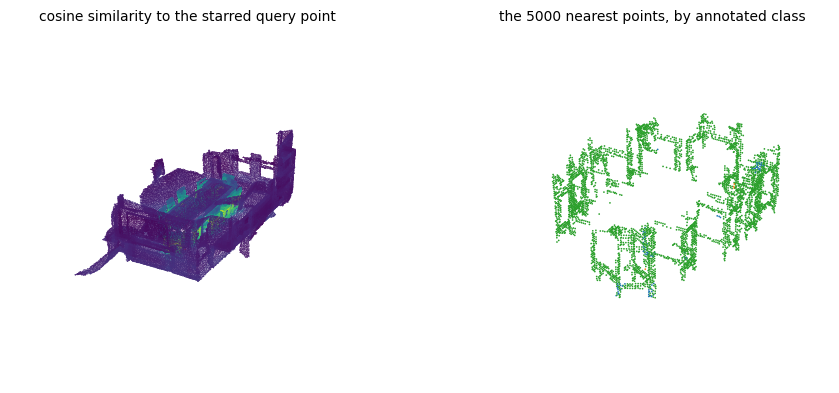

In [16]:
top = similarity.topk(5000).indices.numpy()
scaled = ((similarity - similarity.min()) / (1 - similarity.min())).numpy()
found = np.unique(segment[top])
palette = {label: plt.get_cmap("tab10")(rank) for rank, label in enumerate(found)}

_, (heat, neighbors) = plt.subplots(1, 2, figsize=(11.0, 4.6), subplot_kw={"projection": "3d"})
heat.scatter(*data["pos_grid"].numpy().T, c=scaled, cmap="viridis", s=0.4, linewidths=0, depthshade=False)
heat.scatter(*data["pos_grid"][query].tolist(), marker="*", s=200, color="red")  # the query point
neighbors.scatter(
    *data["pos_grid"][top].numpy().T,
    c=[palette[label] for label in segment[top]],
    s=1.5,
    linewidths=0,
    depthshade=False,
)
titles = ["cosine similarity to the starred query point", "the 5000 nearest points, by annotated class"]
for ax, title in zip((heat, neighbors), titles):
    ax.set_box_aspect(np.ptp(data["pos_grid"].numpy(), axis=0))
    ax.set_title(title, fontsize=10)
    ax.set_axis_off()
plt.show()

![similar objects.](../assets/tutorials/query_similarity.png)

## Retrieve whole shapes

Here we will use the same logic but to retrieve objects from a classification dataset (ModelNet40).

In [19]:
from torch_pointcloud.datasets import ModelNetNormalResampled
from torch_pointcloud.utils.data import PointCloudDataLoader

encoder, info = tp.create_model(
    "pointnet2-ssg.modelnet40.xu-yan",
    task="classification",
    pretrained=True,
    num_classes=0,
    return_info=True,
)
encoder = encoder.eval().to(device)

dataset = ModelNetNormalResampled(
    root="data", 
    variant="40", 
    train=False, 
    transform=info["transform"],
    download=True,
)
dataloader = PointCloudDataLoader(dataset, batch_size=64, num_workers=6)

index, labels = [], []
with torch.inference_mode():
    for item in dataloader:
        embedding = encoder(None, item["pos"].to(device), item["batch"].to(device))
        index.append(F.normalize(embedding, dim=-1).cpu())  # normalize once, at write time
        labels.append(item["label"])

index, labels = torch.cat(index), torch.cat(labels)
print("index:", tuple(index.shape), f"| {index.numel() * index.element_size() / 1e6:.1f} MB float32")

Downloading: 100%|██████████| 1.58G/1.58G [01:04<00:00, 26.5MB/s]  
Processing: 100%|██████████| 2468/2468 [00:06<00:00, 404.29it/s]


index: (2468, 1024) | 10.1 MB float32


In [20]:
similarity = index @ index.t()
similarity.fill_diagonal_(-1.0)  # never retrieve the query itself
nearest = similarity.argmax(dim=1)
top5 = similarity.topk(5, dim=1).indices

print(f"1-NN retrieval accuracy: {(labels[nearest] == labels).float().mean():.4f}")
print(f"top-5 class purity:      {(labels[top5] == labels[:, None]).float().mean():.4f}")
print(f"5-NN vote accuracy:      {(torch.mode(labels[top5], dim=1).values == labels).float().mean():.4f}")

1-NN retrieval accuracy: 0.8825
top-5 class purity:      0.8545
5-NN vote accuracy:      0.8918


```text
1-NN retrieval accuracy: 0.8825
top-5 class purity:      0.8545
5-NN vote accuracy:      0.8918
```

88.25% of the split retrieves an object of its own class first, against **92.30%** for the same checkpoint's trained
classification head. The head was fitted to these 40 classes; the search was not told the classes exist.

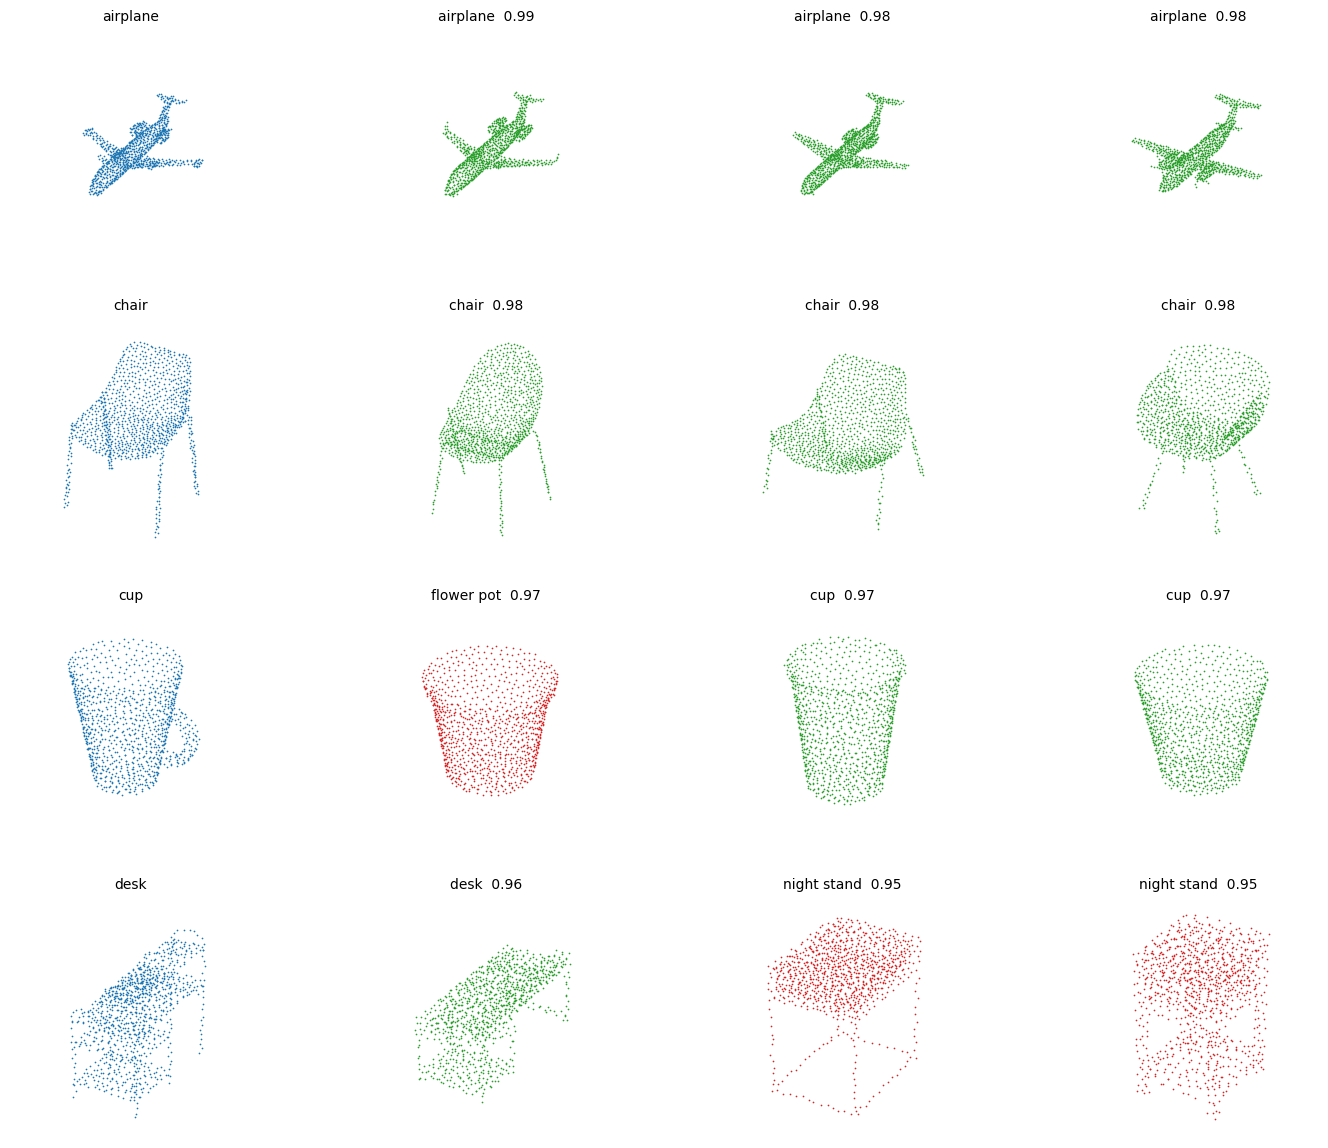

In [21]:
names = {value: key for key, value in dataset.class_to_idx.items()}
roles = ("tab:blue", "tab:green", "tab:red")  # the query, a neighbor of its class, a neighbor of another

gallery, titles = [], []
for name in ("airplane", "chair", "cup", "desk"):
    query = int((labels == dataset.class_to_idx[name]).nonzero()[0])
    for rank, found in enumerate([query, *top5[query, :3].tolist()]):
        pos = dataset[found]["pos"][:, [0, 2, 1]]  # the dataset is y-up, the figure is z-up
        role = 0 if rank == 0 else int(labels[found] != labels[query]) + 1
        gallery.append({"pos": pos, "color": roles[role]})
        title = names[int(labels[found])].replace("_", " ")
        titles.append(title if rank == 0 else f"{title}  {float(similarity[query, found]):.2f}")

show_clouds(gallery, titles, point_size=1.5, columns=4, height=3.6)

![retrieval](../assets/tutorials/retrieval_gallery.png)

We can also use the PCA to visualize the embedding space (in 2D) of each object of the dataset to visualize if classes are well separated in the PCA space.

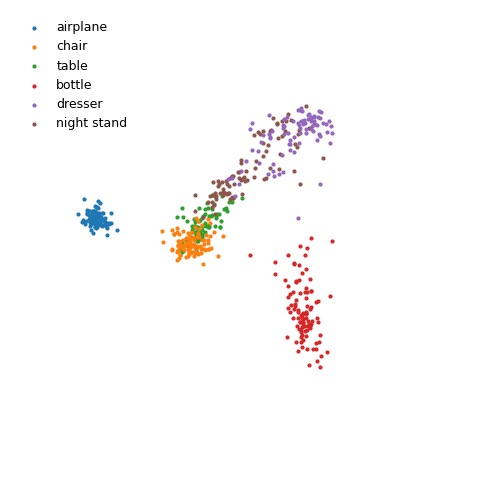

In [ ]:
shown = ["airplane", "chair", "table", "bottle", "dresser", "night_stand"]
ids = torch.tensor([dataset.class_to_idx[name] for name in shown])
lookup = torch.full((len(dataset.class_to_idx),), -1, dtype=torch.long)
lookup[ids] = torch.arange(len(shown))  # palette index of each drawn class, -1 for the rest
keep = lookup[labels] >= 0

descriptors = index[keep]
_, _, components = torch.pca_lowrank(descriptors, center=True, q=3, niter=8)
projected = ((descriptors - descriptors.mean(0)) @ components).numpy()
drawn = lookup[labels[keep]].numpy()

_, ax = plt.subplots(figsize=(7.5, 6.0), subplot_kw={"projection": "3d"})
for rank, name in enumerate(shown):
    ax.scatter(*projected[drawn == rank].T, s=4.0, label=name.replace("_", " "), depthshade=False)

ax.legend(loc="upper left", frameon=False, fontsize=9)
ax.set_axis_off()
plt.show()

![PCA separation of ModelNet40 classes](../assets/tutorials/embedding_map.png)

Airplane holds a region of its own and retrieves its own class for all 100 of its test objects but night stand and dresser objects are close to each other, which is a current limitation of this encoder.